Fitness Activity Video Classification - Task 3

1. Imports

In [1]:
import numpy as np
import tensorflow as tf

print("Python OK")
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

Python OK
NumPy: 2.2.5
TensorFlow: 2.20.0


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("TensorFlow:", tf.__version__)

C:\Users\Yo\anaconda3\envs\workout_vision\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



TensorFlow: 2.20.0


2. Data set configuration

In [3]:
dataset_path = r"C:\Users\Yo\Downloads\KTH-P3-2026\Data Mining\Final Assingment\archive"

activities = [
    "barbell biceps curl",
    "bench press",
    "deadlift",
    "plank",
    "pull Up",
    "push-up",
    "shoulder press",
    "squat"
]

FRAMES = 16
HEIGHT = 224
WIDTH = 224

print("Activities:", activities)

Activities: ['barbell biceps curl', 'bench press', 'deadlift', 'plank', 'pull Up', 'push-up', 'shoulder press', 'squat']


3. Load Video Function

In [4]:
def load_video(path):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frames = []
    frame_indices = np.linspace(0, total_frames - 1, FRAMES).astype(int)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (WIDTH, HEIGHT))
        frame = frame.astype("float32") / 255.0
        frames.append(frame)

    cap.release()

    while len(frames) < FRAMES:
        frames.append(np.zeros((HEIGHT, WIDTH, 3), dtype=np.float32))

    return np.array(frames)

4. Load Dataset

In [5]:
X = []
y = []

for activity in activities:
    activity_path = os.path.join(dataset_path, activity)

    for video_file in tqdm(os.listdir(activity_path)):
        video_path = os.path.join(activity_path, video_file)

        video = load_video(video_path)

        if video.shape == (FRAMES, HEIGHT, WIDTH, 3):
            X.append(video)
            y.append(activity)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:35<00:00,  1.22s/it]


Dataset shape: (290, 16, 224, 224, 3)
Labels shape: (290,)


5. Encode Labels

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (232, 16, 224, 224, 3)
Test shape: (58, 16, 224, 224, 3)


6. Load MoViNet Feature Extractor

In [7]:
import os
os.environ["TFHUB_CACHE_DIR"] = r"C:\tfhub_cache"

In [8]:
import tensorflow as tf
import tensorflow_hub as hub

In [9]:
hub_url = "https://www.kaggle.com/models/google/movinet/TensorFlow2/a0-base-kinetics-600-classification/3"
movinet = hub.load(hub_url)
print("MoViNet loaded")

MoViNet loaded


7. Load MoViNet Feature Extractor

In [10]:
sample = tf.convert_to_tensor(X_train[0], dtype=tf.float32)
sample = tf.expand_dims(sample, axis=0)
out = movinet({'image': sample})

print(type(out))
print(out.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 600)


In [11]:
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(232, 16, 224, 224, 3)


In [13]:
from tqdm import tqdm

def extract_features(dataset):
    features = []

    for video in tqdm(dataset, desc="Extracting features"):
        video = tf.convert_to_tensor(video, dtype=tf.float32)
        video_batch = tf.expand_dims(video, axis=0)

        outputs = movinet({'image': video_batch})
        feature_vector = outputs.numpy()[0]
        features.append(feature_vector)

    return np.array(features)

In [17]:
train_features = extract_features(X_train)
print("Train features shape:", train_features.shape)

test_features = extract_features(X_test)
print("Test features shape:", test_features.shape)


Extracting features: 100%|███████████████████████████████████████████████████████████| 232/232 [13:13<00:00,  3.42s/it]


Train features shape: (232, 600)


Extracting features: 100%|█████████████████████████████████████████████████████████████| 58/58 [05:09<00:00,  5.33s/it]

Test features shape: (58, 600)


8. Build Classifier

In [18]:
NUM_CLASSES = len(activities)

classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(train_features.shape[1],)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

classifier.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         307,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           4,104 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 311,816 (1.19 MB)

 Trainable params: 311,816 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

9. Train

In [19]:
history = classifier.fit(
    train_features,
    y_train,
    validation_data=(test_features, y_test),
    epochs=10,
    batch_size=8
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8147 - loss: 0.6844 - val_accuracy: 0.9483 - val_loss: 0.2074
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9914 - loss: 0.0235 - val_accuracy: 0.9310 - val_loss: 0.1496
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9957 - loss: 0.0195 - val_accuracy: 0.9138 - val_loss: 0.2133
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.9138 - val_loss: 0.1633
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9138 - val_loss: 0.1553
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9138 - val_loss: 0.1341
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9310 - val_loss: 0.1372
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.7610e-04 - val_accuracy: 0.9310 - val_

10. Evaluate

In [20]:
test_loss, test_acc = classifier.evaluate(test_features, y_test)
print("Test accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9483 - loss: 0.1438
Test accuracy: 0.9482758641242981


11. Confusion Matirx

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


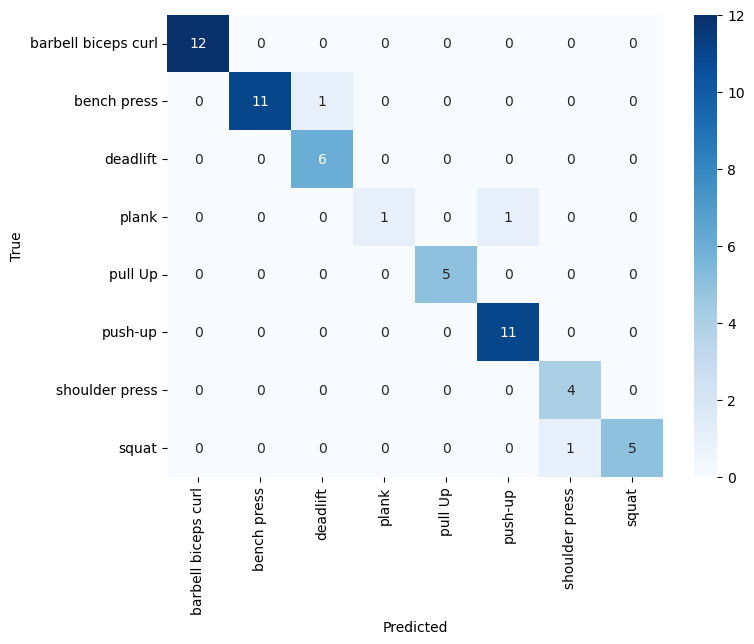

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = classifier.predict(test_features).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=activities,
            yticklabels=activities)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()